# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Подготовка df

In [2]:
ingredient_rating_columns = ['rating',
    'almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice', 'apricot',
    'artichoke', 'arugula', 'asian pear', 'asparagus', 'avocado',
    'bacon', 'banana', 'barley', 'basil', 'bass', 'bean', 'beef', 'beef rib',
    'beef shank', 'beef tenderloin', 'beer', 'beet', 'bell pepper', 'berry',
    'biscuit', 'bitters', 'blackberry', 'blue cheese', 'blueberry', 'bok choy',
    'bourbon', 'bran', 'brandy', 'bread', 'breadcrumbs', 'brie', 'brisket',
    'broccoli', 'broccoli rabe', 'brown rice', 'brownie', 'brussel sprout',
    'bulgur', 'butter', 'buttermilk', 'butternut squash', 'butterscotch/caramel',
    'cabbage', 'cake', 'calvados', 'campari', 'candy', 'cantaloupe', 'capers',
    'caraway', 'cardamom', 'carrot', 'cashew', 'cauliflower', 'caviar', 'celery',
    'chambord', 'champagne', 'chard', 'chartreuse', 'cheddar', 'cheese', 'cherry',
    'chestnut', 'chicken', 'chickpea', 'chile', 'chile pepper', 'chili', 'chive',
    'chocolate', 'cilantro', 'cinnamon', 'citrus', 'clam', 'clove', 'coconut',
    'cod', 'coffee', 'cognac/armagnac', 'collard greens', 'cookie', 'cookies',
    'coriander', 'corn', 'cornmeal', 'cottage cheese', 'couscous', 'crab',
    'cranberry', 'cranberry sauce', 'cream cheese', 'créme de cacao', 'crêpe',
    'cr��me de cacao', 'cucumber', 'cumin', 'cupcake', 'currant', 'curry',
    'date', 'dill', 'dried fruit', 'duck', 'eau de vie', 'egg', 'egg nog',
    'eggplant', 'endive', 'escarole', 'fennel', 'feta', 'fig', 'fish',
    'flat bread', 'fontina', 'fortified wine', 'frangelico',
    'fruit juice', 'game', 'garlic', 'gin', 'ginger', 'goat cheese', 'goose',
    'gouda', 'grains', 'grand marnier', 'granola', 'grape', 'grapefruit',
    'grappa', 'green bean', 'green onion/scallion', 'ground beef', 'ground lamb',
    'guava', 'halibut', 'ham', 'hazelnut', 'herb', 'hominy/cornmeal/masa',
    'honey', 'honeydew', 'horseradish', 'hot pepper', 'hummus', 'ice cream',
    'iced coffee', 'iced tea', 'jalapeño', 'jam or jelly', 'jerusalem artichoke',
    'jícama', 'kahlúa', 'kale', 'kirsch', 'kiwi', 'kumquat', 'lamb', 'lamb chop',
    'lamb shank', 'leafy green', 'leek', 'legume', 'lemon', 'lemon juice',
    'lemongrass', 'lentil', 'lettuce', 'lima bean', 'lime', 'lime juice',
    'lingonberry', 'liqueur', 'lobster', 'lychee', 'macadamia nut', 'mango',
    'maple syrup', 'marsala', 'marscarpone', 'marshmallow', 'mayonnaise', 'meat',
    'melon', 'mezcal', 'midori', 'milk/cream', 'mint', 'molasses', 'monterey jack',
    'mozzarella', 'muffin', 'mushroom', 'mussel', 'mustard', 'mustard greens',
    'nectarine', 'noodle', 'nut', 'nutmeg', 'oat', 'oatmeal', 'octopus', 'okra',
    'olive', 'onion', 'orange', 'orange juice', 'oregano', 'orzo', 'oyster',
    'pancake', 'papaya', 'paprika', 'parmesan', 'parsley', 'parsnip', 'passion fruit',
    'pasta', 'pastry', 'pea', 'peach', 'peanut', 'peanut butter', 'pear', 'pecan',
    'pepper', 'pernod', 'persimmon', 'phyllo/puff pastry dough', 'pickles',
    'pine nut', 'pineapple', 'pistachio', 'plantain', 'plum', 'poblano',
    'pomegranate', 'pomegranate juice', 'poppy', 'pork', 'pork chop', 'pork rib',
    'pork tenderloin', 'port', 'potato', 'poultry', 'poultry sausage', 'prosciutto',
    'prune', 'pumpkin', 'quail', 'quince', 'quinoa', 'rabbit', 'rack of lamb',
    'radicchio', 'radish', 'raisin', 'raspberry', 'red wine', 'rhubarb', 'rice',
    'ricotta', 'root vegetable', 'rosemary', 'rosé', 'rum', 'rutabaga', 'rye',
    'saffron', 'sage', 'sake', 'salmon', 'salsa', 'sangria', 'sardine', 'sausage',
    'scallop', 'scotch', 'seafood', 'seed', 'semolina', 'sesame', 'sesame oil',
    'shallot', 'shellfish', 'sherry', 'shrimp', 'smoothie', 'snapper', 'sorbet',
    'sour cream', 'sourdough', 'soy', 'soy sauce', 'sparkling wine', 'spice',
    'spinach', 'spirit', 'squash', 'squid', 'steak', 'stock', 'strawberry',
    'sugar snap pea', 'sweet potato/yam', 'swiss cheese', 'swordfish', 'tamarind',
    'tangerine', 'tapioca', 'tarragon', 'tea', 'tequila', 'thyme', 'tilapia',
    'tofu', 'tomatillo', 'tomato', 'tortillas', 'tree nut', 'triple sec',
    'tropical fruit', 'trout', 'tuna', 'turkey', 'turnip', 'vanilla', 'veal',
    'vegetable', 'venison', 'vermouth', 'vinegar', 'vodka', 'waffle', 'walnut',
    'wasabi', 'watercress', 'watermelon', 'whiskey', 'white wine', 'whole wheat',
    'wild rice', 'wine', 'yellow squash', 'yogurt', 'yuca', 'zucchini'
]
df = pd.read_csv("../kaggle/epi_r.csv")
df = df[ingredient_rating_columns]

In [3]:
prep_points = 0
max_prep_points = 0
# Условия с "нет" (отсутствие колонки)
if 'title' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'leftovers' not in df.columns:
    prep_points += 1
max_prep_points += 1 
if 'california' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'dominican republic' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'protein' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'low cholesterol' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'pan-fry' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'fruit' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'stew' not in df.columns:
    prep_points += 1
max_prep_points += 1
if 'braise' not in df.columns:
    prep_points += 1
max_prep_points += 1

# Условия с "есть" (наличие колонки)
if any(col in df.columns for col in ['milk', 'milk/cream']):
    prep_points += 1
max_prep_points += 1
if any(col in df.columns for col in ['jam', 'jam or jelly']):
    prep_points += 1
max_prep_points += 1


print(f"Итоговое количество очков подготовки: {prep_points}")
print(f"Максимальное количество очков подготовки: {max_prep_points}")

Итоговое количество очков подготовки: 12
Максимальное количество очков подготовки: 12


In [4]:
df.head()

,rating,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,...,watermelon,whiskey,white wine,whole wheat,wild rice,wine,yellow squash,yogurt,yuca,zucchini
0,2.500,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.750,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(len(df.columns))
print(len(df))

359
20052


In [6]:
print(df['rating'].value_counts().sort_index(ascending=False))

rating
5.000    2719
4.375    8019
3.750    5169
3.125    1489
2.500     532
1.875     124
1.250     164
0.000    1836
Name: count, dtype: int64


<Axes: xlabel='rating'>

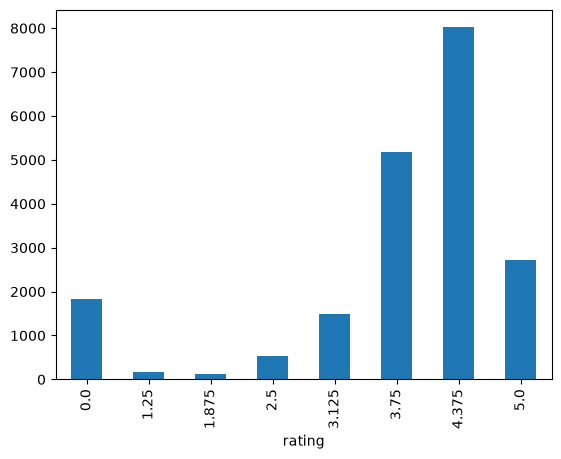

In [7]:
df['rating'].value_counts().sort_index().plot(kind='bar')

In [8]:
X = df.drop('rating', axis=1)
y = df['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Выбор моделей регрессии

### Линейные модели

#### Ridge

In [21]:
param_grid_ridge = {
    'alpha': range(23, 28, 1),
    'solver': ['lsqr', 'saga']
}

ridge_search = GridSearchCV(
    Ridge(),
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': range(23, 28), 'solver': ['lsqr', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a 

In [22]:
res_ridge = pd.DataFrame(ridge_search.cv_results_).sort_values('rank_test_score')
print(ridge_search.best_params_)
res_ridge.head(5)

{'alpha': 24, 'solver': 'lsqr'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.185003,0.010102,0.009640,0.000696,24,lsqr,"{'alpha': 24, 'solver': 'lsqr'}",-1.277312,-1.294549,-1.271530,-1.289824,-1.266519,-1.279947,0.010667,1
4,0.184139,0.006580,0.009599,0.001098,25,lsqr,"{'alpha': 25, 'solver': 'lsqr'}",-1.277287,-1.294384,-1.271650,-1.289943,-1.266472,-1.279947,0.010638,2
6,0.190493,0.009057,0.010059,0.000502,26,lsqr,"{'alpha': 26, 'solver': 'lsqr'}",-1.277268,-1.294228,-1.271756,-1.290061,-1.266433,-1.279949,0.010613,3
0,0.236708,0.018829,0.010768,0.000414,23,lsqr,"{'alpha': 23, 'solver': 'lsqr'}",-1.277338,-1.294723,-1.271409,-1.289705,-1.266571,-1.279949,0.010697,4
3,0.725065,0.038573,0.010156,0.000923,24,saga,"{'alpha': 24, 'solver': 'saga'}",-1.277336,-1.294546,-1.271541,-1.289835,-1.266505,-1.279953,0.010668,5


In [23]:
ridge = Ridge(**ridge_search.best_params_)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

1.277536752084953


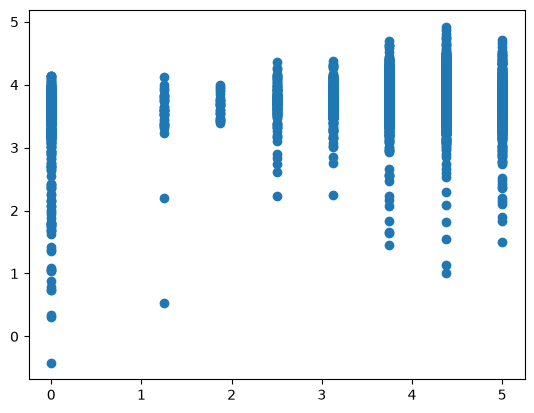

In [24]:
print(root_mean_squared_error(y_test, ridge_pred))
plt.scatter(y_test, ridge_pred)

#### Lasso

In [25]:
param_grid_lasso = {
    'alpha': [0, 0.001, 0.005],
    'max_iter' : [5000]
}

lasso_search = GridSearchCV(
    Lasso(),
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0, 0.001, ...], 'max_iter': [5000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom

In [26]:
res_lasso = pd.DataFrame(lasso_search.cv_results_).sort_values('rank_test_score')
print(lasso_search.best_params_)
res_lasso.head(5)

{'alpha': 0.001, 'max_iter': 5000}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.110148,0.005291,0.010676,0.001506,0.001,5000,"{'alpha': 0.001, 'max_iter': 5000}",-1.279770,-1.294629,-1.274995,-1.294050,-1.267016,-1.282092,0.010800,1
0,0.119698,0.003585,0.011230,0.000952,0.000,5000,"{'alpha': 0, 'max_iter': 5000}",-1.287567,-1.309802,-1.270689,-1.293722,-1.279312,-1.288219,0.013291,2
2,0.100436,0.004978,0.010520,0.001023,0.005,5000,"{'alpha': 0.005, 'max_iter': 5000}",-1.300513,-1.301297,-1.294362,-1.317100,-1.281687,-1.298992,0.011458,3


In [27]:
lasso = Lasso(**lasso_search.best_params_)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

1.282631448168515


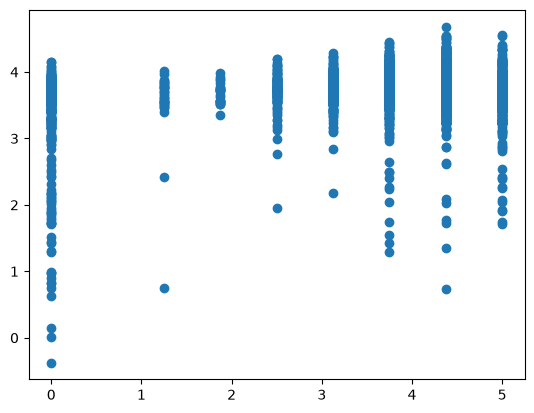

In [28]:
print(root_mean_squared_error(y_test, lasso_pred))
plt.scatter(y_test, lasso_pred)

#### ElasticNet

In [29]:
param_grid_enet = {
    'alpha': [0, 0.0001, 0.001, 0.01],
    'l1_ratio': [0.001, 0.01, 0.1],
    'max_iter': [5000]
}

enet_search = GridSearchCV(
    ElasticNet(),
    param_grid=param_grid_enet,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

enet_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0, 0.0001, ...], 'l1_ratio': [0.001, 0.01, ...], 'max_iter': [5000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_d

In [30]:
res_enet = pd.DataFrame(enet_search.cv_results_).sort_values('rank_test_score')
print(enet_search.best_params_)
res_enet.head(5)

{'alpha': 0.001, 'l1_ratio': 0.1, 'max_iter': 5000}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.114179,0.007040,0.010760,0.000819,0.0010,0.100,5000,"{'alpha': 0.001, 'l1_ratio': 0.1, 'max_iter': ...",-1.277693,-1.296076,-1.270152,-1.288145,-1.266536,-1.279721,0.011027,1
7,0.131886,0.007597,0.011094,0.000529,0.0010,0.010,5000,"{'alpha': 0.001, 'l1_ratio': 0.01, 'max_iter':...",-1.278126,-1.297070,-1.270182,-1.288468,-1.267374,-1.280244,0.011155,2
6,0.136944,0.003100,0.010028,0.000424,0.0010,0.001,5000,"{'alpha': 0.001, 'l1_ratio': 0.001, 'max_iter'...",-1.278178,-1.297190,-1.270189,-1.288510,-1.267473,-1.280308,0.011171,3
5,0.135956,0.009788,0.010516,0.001099,0.0001,0.100,5000,"{'alpha': 0.0001, 'l1_ratio': 0.1, 'max_iter':...",-1.283055,-1.305030,-1.269083,-1.289357,-1.273252,-1.283956,0.012727,4
4,0.154207,0.005070,0.010129,0.000901,0.0001,0.010,5000,"{'alpha': 0.0001, 'l1_ratio': 0.01, 'max_iter'...",-1.283202,-1.305208,-1.269182,-1.289511,-1.273387,-1.284098,0.012751,5


In [31]:
enet = ElasticNet(**enet_search.best_params_)
enet.fit(X_train, y_train)
enet_pred = enet.predict(X_test)

1.2780094199513479


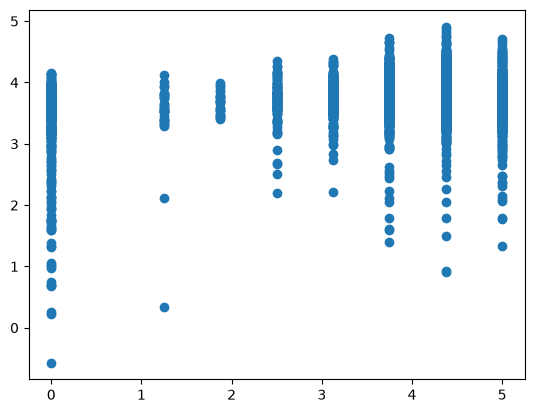

In [32]:
print(root_mean_squared_error(y_test, enet_pred))
plt.scatter(y_test, enet_pred)

### Ансамбли

#### RandomForest

In [37]:
param_grid_rf = {
    'n_estimators': [200],
    'max_depth': range(50, 100, 20),
    'min_samples_split': range(2, 5, 1),
    'max_features': ['sqrt'],
}

rf_search = GridSearchCV(
    RandomForestRegressor(),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(50, 100, 20), 'max_features': ['sqrt'], 'min_samples_split': range(2, 5), 'n_estimators': [200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [38]:
res_rf = pd.DataFrame(rf_search.cv_results_).sort_values('rank_test_score')
print(rf_search.best_params_)
res_rf.head(5)

{'max_depth': 90, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 200}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,17.967947,0.528761,0.260762,0.017347,90,sqrt,4,200,"{'max_depth': 90, 'max_features': 'sqrt', 'min...",-1.275347,-1.269068,-1.253476,-1.267101,-1.237397,-1.260478,0.013568,1
4,25.414088,0.882777,0.727314,0.078278,70,sqrt,3,200,"{'max_depth': 70, 'max_features': 'sqrt', 'min...",-1.275461,-1.272280,-1.255552,-1.269038,-1.237246,-1.261915,0.014076,2
5,23.913166,1.047397,0.696250,0.058716,70,sqrt,4,200,"{'max_depth': 70, 'max_features': 'sqrt', 'min...",-1.271661,-1.272786,-1.255942,-1.269510,-1.241365,-1.262253,0.012069,3
7,25.519530,1.080026,0.451329,0.090536,90,sqrt,3,200,"{'max_depth': 90, 'max_features': 'sqrt', 'min...",-1.275525,-1.272735,-1.257745,-1.268412,-1.237723,-1.262428,0.013754,4
1,19.584491,0.490561,0.616056,0.060065,50,sqrt,3,200,"{'max_depth': 50, 'max_features': 'sqrt', 'min...",-1.274497,-1.275078,-1.258227,-1.272360,-1.244053,-1.264843,0.012087,5


In [39]:
rf = RandomForestRegressor(**rf_search.best_params_)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

1.2572860401400532


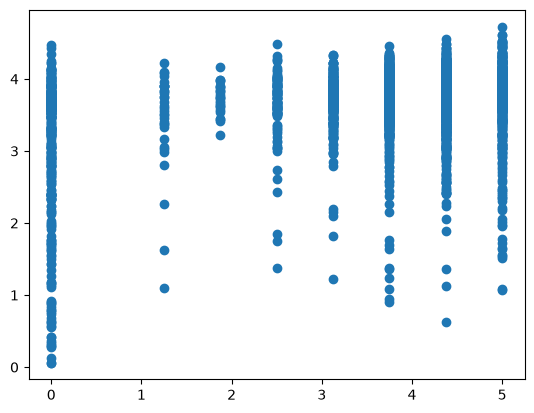

In [40]:
print(root_mean_squared_error(y_test, rf_pred))
plt.scatter(y_test, rf_pred)

#### GradientBoostingRegressor

In [41]:
param_grid_gb = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [15],
    'min_samples_split': [5, 10],
    'subsample': [0.8],
    'loss' : ['absolute_error']
}

gb_search = GridSearchCV(
    GradientBoostingRegressor(),
    param_grid=param_grid_gb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1], 'loss': ['absolute_error'], 'max_depth': [15], 'min_samples_split': [5, 10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_e

In [42]:
res_gb = pd.DataFrame(gb_search.cv_results_).sort_values('rank_test_score')
print(gb_search.best_params_)
res_gb.head(5)

{'learning_rate': 0.1, 'loss': 'absolute_error', 'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_loss,param_max_depth,param_min_samples_split,param_n_estimators,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,27.204492,0.360926,0.044924,0.002671,0.1,absolute_error,15,10,100,0.8,"{'learning_rate': 0.1, 'loss': 'absolute_error...",-1.388296,-1.385370,-1.383710,-1.407369,-1.363208,-1.385591,0.014044,1
0,27.830716,0.222655,0.055606,0.013756,0.1,absolute_error,15,5,100,0.8,"{'learning_rate': 0.1, 'loss': 'absolute_error...",-1.391945,-1.391934,-1.388102,-1.402934,-1.375178,-1.390018,0.008923,2


In [43]:
gb = GradientBoostingRegressor(**gb_search.best_params_)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

1.3938268192391408


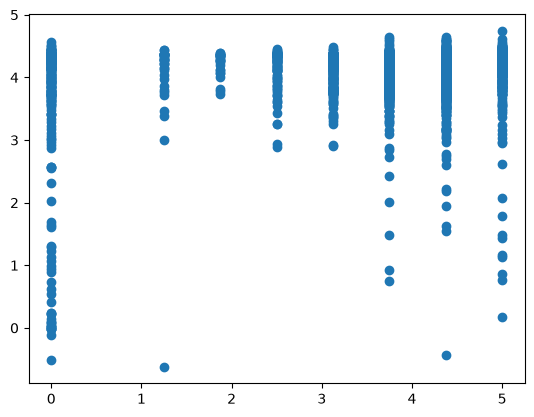

In [44]:
print(root_mean_squared_error(y_test, gb_pred))
plt.scatter(y_test, gb_pred)

#### HistGradientBoostingRegressor

In [ ]:
param_grid_hgb = {
    'max_iter': [100],
    'learning_rate': [0.1, 0.2],
    'max_depth': [10],
    'min_samples_leaf': [20, 50],
    'l2_regularization': [0.1, 1.0],
    'loss' : ['absolute_error']
}

hgb_search = GridSearchCV(
    HistGradientBoostingRegressor(),
    param_grid=param_grid_hgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
res_hgb = pd.DataFrame(hgb_search.cv_results_).sort_values('rank_test_score')
print(hgb_search.best_params_)
res_hgb.head(5)

{'l2_regularization': 0.1, 'learning_rate': 0.2, 'loss': 'absolute_error', 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 20}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_loss,param_max_depth,param_max_iter,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,6.201816,1.396920,0.068339,0.018802,0.1,0.2,absolute_error,7,100,20,"{'l2_regularization': 0.1, 'learning_rate': 0....",-1.448307,-1.377849,-1.474578,-1.436489,-1.416720,-1.430789,0.032427,1
3,7.522528,2.622164,0.084414,0.022578,0.1,0.1,absolute_error,7,100,50,"{'l2_regularization': 0.1, 'learning_rate': 0....",-1.462011,-1.382107,-1.464120,-1.435479,-1.413972,-1.431538,0.030847,2
14,3.392395,1.395802,0.036402,0.008810,1.0,0.2,absolute_error,7,100,20,"{'l2_regularization': 1.0, 'learning_rate': 0....",-1.458552,-1.390243,-1.456323,-1.439494,-1.418493,-1.432621,0.025601,3
15,2.553094,0.749539,0.032827,0.007002,1.0,0.2,absolute_error,7,100,50,"{'l2_regularization': 1.0, 'learning_rate': 0....",-1.463858,-1.379349,-1.470584,-1.441732,-1.419938,-1.435092,0.033070,4
4,4.980814,1.327484,0.060438,0.013905,0.1,0.2,absolute_error,5,100,20,"{'l2_regularization': 0.1, 'learning_rate': 0....",-1.461918,-1.398191,-1.465227,-1.434912,-1.418984,-1.435846,0.025480,5


In [ ]:
hgb = HistGradientBoostingRegressor(**hgb_search.best_params_)
hgb.fit(X_train, y_train)
hgb_pred = gb.predict(X_test)

1.3874711286041412


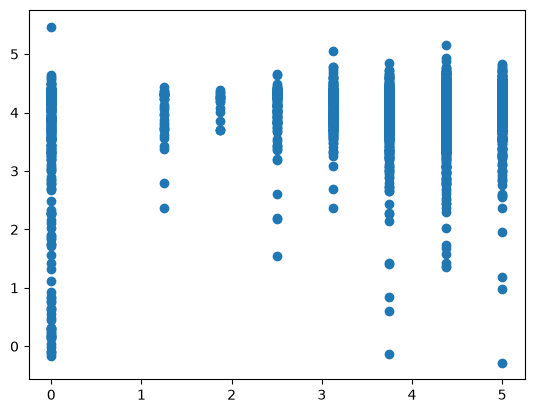

In [ ]:
print(root_mean_squared_error(y_test, hgb_pred))
plt.scatter(y_test, hgb_pred)

### Прочие модели

#### SVR

In [129]:
param_grid_svr = {
    'kernel': ['rbf'],
    'C': [1.0, 10.0],
    'gamma': ['scale', 0.01],
    'epsilon': [0.1],
    'max_iter' : [100]
}

svr_search = GridSearchCV(
    SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

svr_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\w1l\21school\code\temp\venv\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1.0, 10.0], 'epsilon': [0.1], 'gamma': ['scale', 0.01], 'kernel': ['rbf'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_d

In [130]:
res_svr = pd.DataFrame(svr_search.cv_results_).sort_values('rank_test_score')
print(svr_search.best_params_)
res_svr.head(5)

{'C': 10.0, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': 100}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_epsilon,param_gamma,param_kernel,param_max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,1.310133,0.208858,0.125501,0.021581,10.0,0.1,scale,rbf,100,"{'C': 10.0, 'epsilon': 0.1, 'gamma': 'scale', ...",-1.460332,-1.655816,-1.518825,-1.681528,-1.862635,-1.635827,0.140298,1
0,2.230670,0.163991,0.263138,0.029466,1.0,0.1,scale,rbf,100,"{'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale', '...",-1.772682,-1.775425,-1.798105,-1.803256,-1.823581,-1.794610,0.018842,2
1,2.201866,0.113215,0.237116,0.051933,1.0,0.1,0.01,rbf,100,"{'C': 1.0, 'epsilon': 0.1, 'gamma': 0.01, 'ker...",-1.825442,-1.812618,-1.824247,-1.825297,-1.823213,-1.822164,0.004840,3
3,1.076820,0.154739,0.114902,0.004534,10.0,0.1,0.01,rbf,100,"{'C': 10.0, 'epsilon': 0.1, 'gamma': 0.01, 'ke...",-1.959427,-1.899306,-1.978456,-1.959289,-1.988504,-1.956996,0.030960,4


In [132]:
svr = SVR(**svr_search.best_params_)
svr.fit(X_train, y_train)
svr_pred = svr.predict(X_test)

c:\Users\w1l\21school\code\temp\venv\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


1.9160500830228584


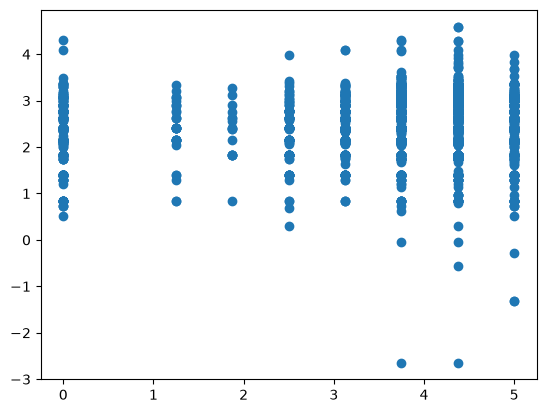

In [133]:
print(root_mean_squared_error(y_test, svr_pred))
plt.scatter(y_test, svr_pred)

#### MLPRegressor

In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50, 25)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.01],
    'learning_rate_init': [0.01],
    'batch_size': [128]
}

mlp_search = GridSearchCV(
    MLPRegressor(),
    param_grid=param_grid_mlp,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['relu'], 'alpha': [0.001, 0.01], 'batch_size': [128], 'hidden_layer_sizes': [(50, ...)], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [12]:
res_mlp = pd.DataFrame(mlp_search.cv_results_).sort_values('rank_test_score')
print(mlp_search.best_params_)
res_mlp.head(5)

{'activation': 'relu', 'alpha': 0.01, 'batch_size': 128, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01, 'solver': 'adam'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,param_batch_size,param_hidden_layer_sizes,param_learning_rate_init,param_solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,61.777951,6.308283,0.052667,0.011373,relu,0.010,128,"(50, 25)",0.01,adam,"{'activation': 'relu', 'alpha': 0.01, 'batch_s...",-1.389571,-1.478800,-1.424854,-1.412363,-1.459694,-1.433056,0.032213,1
0,65.833776,6.811899,0.054532,0.012536,relu,0.001,128,"(50, 25)",0.01,adam,"{'activation': 'relu', 'alpha': 0.001, 'batch_...",-1.423729,-1.532966,-1.469097,-1.458176,-1.480687,-1.472931,0.035546,2


In [14]:
mlp = MLPRegressor(**mlp_search.best_params_)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

1.4211941847764002


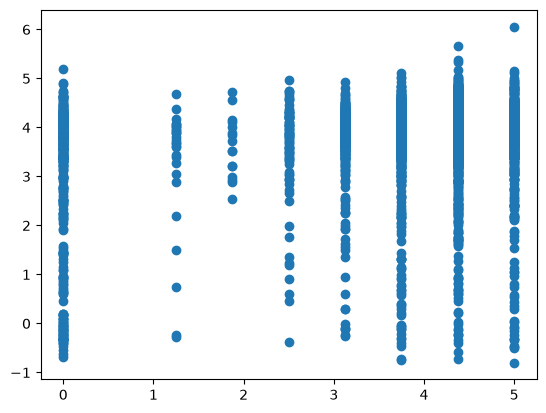

In [15]:
print(root_mean_squared_error(y_test, mlp_pred))
plt.scatter(y_test, mlp_pred)

# Подготовка данных для классификации

In [19]:
y, y_train, y_test = y.round(0), y_train.round(0), y_test.round(0)

# Выбор модели

## LogisticRegression

In [ ]:
param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs'],
    'multi_class': ['multinomial'],
    'max_iter': [1000]
}

skf = StratifiedKFold(n_splits=5, shuffle=True)

lr_search = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param_grid_lr,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

In [ ]:
lr_res = pd.DataFrame(lr_search.cv_results_).sort_values('rank_test_score')
print(lr_search.best_params_)
lr_res.head(5)

In [ ]:
lr = HistGradientBoostingRegressor(**lr_search.best_params_)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
print(root_mean_squared_error(y_test, lr_pred))
plt.scatter(y_test, lr_pred)